# Notebook 06 — Comparing Poisson and Hawkes Fill Dynamics

**Paper**: Guéant (2017), *Optimal Market Making* — baseline Poisson model  
**Extension reference**: Lalor & Swishchuk (2025), arXiv:2502.17417 — Neural Hawkes Process for LOB

## Purpose

The Guéant (2017) framework assumes fills arrive as a **memoryless Poisson process**
with intensity $\Lambda(\delta) = A e^{-k\delta}$. In real order books, fills **cluster in time**:
a trade triggers more trades, creating bursts of activity.

This notebook introduces a **Hawkes self-excitation** mechanism on top of the
Poisson baseline and compares the two models.

> **Important caveat.** This notebook is a **stylized demonstration**, not a
> calibrated empirical comparison. The parameters used here are toy proxies chosen
> to make the effect of self-excitation clearly visible. They are *not* the
> Guéant (2017) CDX-index parameters ($A_{\text{IG}} = 9.1 \times 10^{-4}$, etc.),
> which are far too small for the clustering effects to be visible on short horizons.

---
## 1. Model Recap

### 1.1 Poisson Intensity (Guéant 2017)

$$\Lambda(\delta) = A \, e^{-k\delta}$$

Over a small time step $dt$, the probability of at least one fill is:

$$\mathbb{P}(\text{fill}) = 1 - e^{-\Lambda(\delta) \, dt}$$

Properties: memoryless, variance = mean, no clustering.

### 1.2 Hawkes-Based Intensity

We add **self-excitation**: each fill temporarily boosts future fill intensity.

$$\lambda_{\text{bid}}(t) = \text{softplus}\!\big(\Lambda(\delta^b) + y_{\text{bid}}(t)\big)$$

where $\text{softplus}(x) = \ln(1 + e^x)$ ensures positivity, and the excitation
state $y(t)$ evolves as:

$$y(t + dt) = y(t) \, e^{-\beta \, dt} \quad \text{(decay between fills)}$$
$$y(t_f^+) = y(t_f^-) + \alpha_{\text{self}} \quad \text{(jump on own fill)}$$
$$y_{\text{other}}(t_f^+) = y_{\text{other}}(t_f^-) + \alpha_{\text{cross}} \quad \text{(cross-excitation)}$$

### 1.3 On the Softplus

When the baseline $\Lambda(\delta)$ is already large and positive,
$\text{softplus}(x) \approx x$. So the nonlinearity mainly matters
when the argument is near zero or negative. For the toy parameters
used here, the Softplus acts almost linearly — the dominant effect
is the **additive excitation shift**, not the nonlinear transformation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
sys.path.append(str(Path().resolve().parents[0]))

from market_making.core.intensity import Lambda, fill_prob
from market_making.core.hawkes import (
    softplus, lambda_hawkes, HawkesState, DEFAULT_HAWKES_CFG,
)

plt.style.use("seaborn-v0_8")

## 2. Parameters

We use **toy proxies** with moderate intensity so that:
- Fill rates are high enough to observe clustering on short horizons ($T = 10$ s)
- But not so high that everything averages out by CLT

These are **not** the Guéant CDX parameters.

| | A | k | Expected Λ(δ=1.5) | Fills in 10s |
|---|---|---|---|---|
| Toy setup | 5.0 | 1.5 | 0.53 /s | ~5 |
| CDX.NA.IG (paper) | 9.1e-4 | 1.79e4 | ≈ 0 | ≈ 0 |

The toy parameters give ~0.5 fills/s at δ=1.5, making clustering
observable without drowning in thousands of fills.

In [2]:
# ── Toy parameters (NOT Guéant paper values) ──────────────────
PARAMS = dict(sigma=0.01, A=5.0, k=1.5, Delta=1.0, Q=4)

HAWKES_CFG = dict(beta=10.0, alpha_self=2.0, alpha_cross=0.5)

C_POISSON = "#2563EB"   # blue
C_HAWKES  = "#DC2626"   # red
C_EXCITED = "#16A34A"   # green

# Verify expected baseline intensity
delta_test = 1.5
lam_test = PARAMS["A"] * np.exp(-PARAMS["k"] * delta_test)
print(f"Baseline intensity at δ={delta_test}: Λ = {lam_test:.3f} fills/s")
print(f"Expected Poisson fills in 10s: {lam_test * 10:.1f}")

Baseline intensity at δ=1.5: Λ = 0.527 fills/s
Expected Poisson fills in 10s: 5.3


## 3. Intensity vs Quote Distance δ

This figure shows how the Softplus Hawkes intensity relates to the Poisson baseline.
For large positive $\Lambda$, $\text{softplus}(\Lambda) \approx \Lambda$, so the
Poisson and Hawkes-at-$y=0$ curves nearly overlap. The main visible effect is
the **vertical shift** from the excitation term $y$.

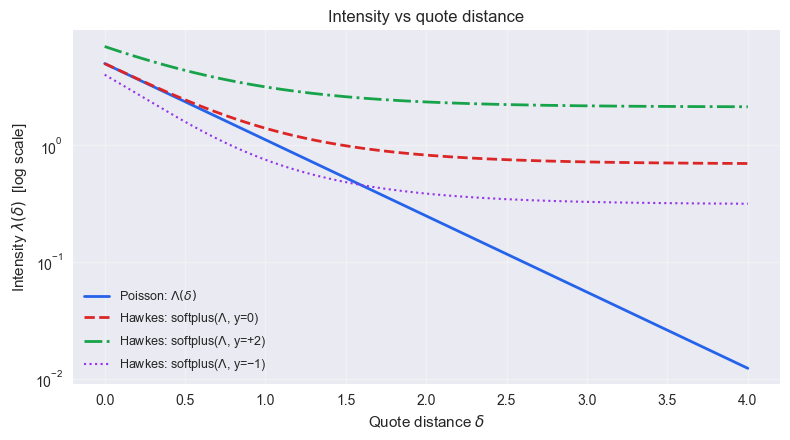

In [3]:
delta = np.linspace(0, 4.0, 300)
A, k = PARAMS["A"], PARAMS["k"]

lam_poisson   = Lambda(delta, A, k)
lam_h0        = lambda_hawkes(lam_poisson, 0.0)
lam_h_excited = lambda_hawkes(lam_poisson, 2.0)
lam_h_inhib   = lambda_hawkes(lam_poisson, -1.0)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(delta, lam_poisson,   color=C_POISSON, lw=2,   label=r"Poisson: $\Lambda(\delta)$")
ax.semilogy(delta, lam_h0,        color=C_HAWKES,  lw=2,   ls="--",
            label=r"Hawkes: softplus($\Lambda$, y=0)")
ax.semilogy(delta, lam_h_excited, color=C_EXCITED, lw=2,   ls="-.",
            label=r"Hawkes: softplus($\Lambda$, y=+2)")
ax.semilogy(delta, lam_h_inhib,   color="#9333EA",  lw=1.5, ls=":",
            label=r"Hawkes: softplus($\Lambda$, y=−1)")
ax.set_xlabel(r"Quote distance $\delta$")
ax.set_ylabel(r"Intensity $\lambda(\delta)$  [log scale]")
ax.set_title("Intensity vs quote distance")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

**Comment.** For these parameters, $\text{softplus}(\Lambda) \approx \Lambda$
when $\Lambda \gg 1$ (small $\delta$). The visible difference comes entirely
from the additive excitation $y$: positive $y$ shifts the curve upward,
negative $y$ shifts it downward. The nonlinear regime of the Softplus
is only active at large $\delta$ where $\Lambda$ is small.

## 4. Excitation Dynamics — the Hawkes Mechanism

This is the clearest illustration of the model. We fix a moderate baseline
$\mu = 1$ fill/s and inject synthetic fills at chosen times. After each fill,
the excitation state $y$ jumps and then decays exponentially.

/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_22792/3003141521.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  axes[0].axhline(float(softplus(np.array([mu]))), color="gray", lw=1, ls=":",


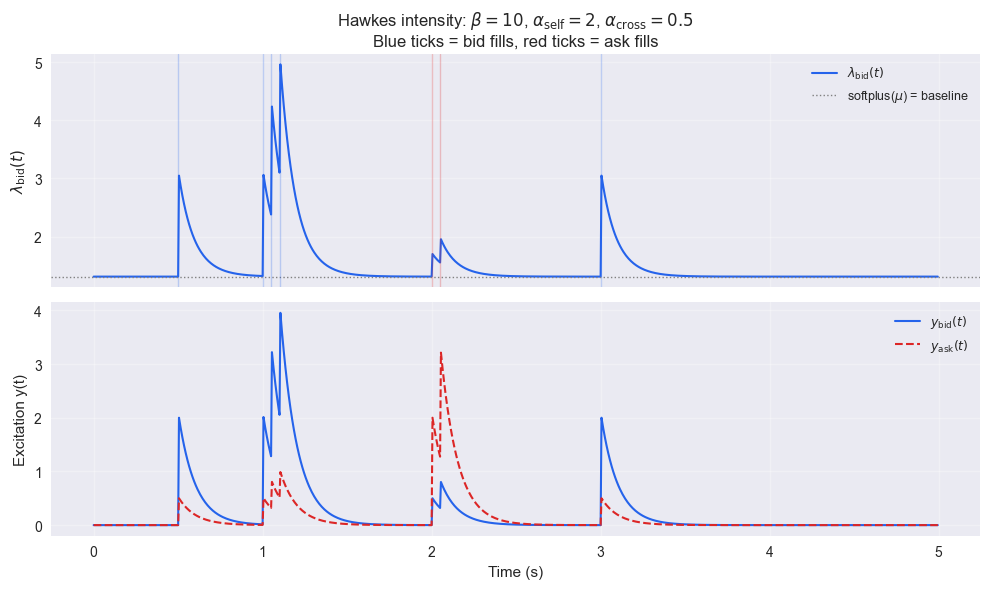

In [4]:
def plot_excitation_dynamics():
    dt   = 0.005
    T    = 5.0
    N    = int(T / dt)
    time = np.arange(N) * dt

    state = HawkesState(HAWKES_CFG)
    mu    = 1.0  # moderate baseline

    y_bid_hist  = np.zeros(N)
    y_ask_hist  = np.zeros(N)
    lam_bid_hist = np.zeros(N)

    # Synthetic fills: a cluster around t=1, isolated fill at t=3
    fill_bid_times = {0.5, 1.0, 1.05, 1.10, 3.0}
    fill_ask_times = {2.0, 2.05}

    for i in range(N):
        t = time[i]
        y_bid_hist[i]    = state.y_bid
        y_ask_hist[i]    = state.y_ask
        lam_bid_hist[i]  = state.lambda_bid(mu)

        fb = any(abs(t - s) < dt / 2 for s in fill_bid_times)
        fa = any(abs(t - s) < dt / 2 for s in fill_ask_times)
        state.step(dt, fb, fa)

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # Top: intensity
    axes[0].plot(time, lam_bid_hist, color=C_POISSON, lw=1.5, label=r"$\lambda_{\mathrm{bid}}(t)$")
    axes[0].axhline(float(softplus(np.array([mu]))), color="gray", lw=1, ls=":",
                    label=r"softplus($\mu$) = baseline")
    for s in sorted(fill_bid_times):
        axes[0].axvline(s, color=C_POISSON, alpha=0.25, lw=1)
    for s in sorted(fill_ask_times):
        axes[0].axvline(s, color=C_HAWKES, alpha=0.25, lw=1)
    axes[0].set_ylabel(r"$\lambda_{\mathrm{bid}}(t)$")
    axes[0].set_title(r"Hawkes intensity: $\beta=10$, $\alpha_{\mathrm{self}}=2$, $\alpha_{\mathrm{cross}}=0.5$"
                      "\nBlue ticks = bid fills, red ticks = ask fills")
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    # Bottom: excitation states
    axes[1].plot(time, y_bid_hist, color=C_POISSON, lw=1.5, label=r"$y_{\mathrm{bid}}(t)$")
    axes[1].plot(time, y_ask_hist, color=C_HAWKES,  lw=1.5, label=r"$y_{\mathrm{ask}}(t)$", ls="--")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("Excitation y(t)")
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()

plot_excitation_dynamics()

**Comment.** This figure shows the core Hawkes mechanism:
each fill temporarily raises future execution intensity, and repeated
nearby fills (the cluster around $t \approx 1$) create short-lived bursts
before decay brings the process back toward baseline. Cross-excitation
from ask fills at $t \approx 2$ also lifts bid intensity, though less strongly.

## 5. Monte Carlo: Poisson vs Hawkes

We now simulate many paths and compare the two models quantitatively.
Instead of only showing a histogram of total fills (which hides clustering
due to CLT averaging), we use **three complementary diagnostics**:

1. **Inter-arrival time distribution** — the gold-standard test for clustering
2. **Fano factor** (variance/mean) — equals 1 for Poisson, > 1 for Hawkes
3. **Fill count histograms** — for completeness

In [5]:
def simulate_one_path(params, cfg, T, dt, delta_bid, delta_ask, mode, rng):
    """Simulate one path. Returns array of fill times (bid+ask combined)."""
    A, k = params["A"], params["k"]
    N = int(T / dt)
    mu_bid = Lambda(delta_bid, A, k)
    mu_ask = Lambda(delta_ask, A, k)

    fill_times = []
    n_fills = 0

    if mode == "poisson":
        for step in range(N):
            t = step * dt
            if rng.random() < fill_prob(mu_bid, dt):
                fill_times.append(t)
                n_fills += 1
            if rng.random() < fill_prob(mu_ask, dt):
                fill_times.append(t)
                n_fills += 1
    else:
        y_bid, y_ask = 0.0, 0.0
        beta = cfg["beta"]
        a_s, a_c = cfg["alpha_self"], cfg["alpha_cross"]
        decay = np.exp(-beta * dt)

        for step in range(N):
            t = step * dt
            lb = float(softplus(np.array([mu_bid + y_bid])))
            la = float(softplus(np.array([mu_ask + y_ask])))

            bf = rng.random() < fill_prob(lb, dt)
            af = rng.random() < fill_prob(la, dt)

            if bf:
                fill_times.append(t)
                n_fills += 1
            if af:
                fill_times.append(t)
                n_fills += 1

            y_bid = y_bid * decay + (a_s if bf else 0) + (a_c if af else 0)
            y_ask = y_ask * decay + (a_s if af else 0) + (a_c if bf else 0)

    return np.sort(fill_times), n_fills


def run_mc(params, cfg, T=10.0, dt=0.001, n_paths=500,
           delta_bid=1.5, delta_ask=1.5, seed=42):
    """Run MC for both Poisson and Hawkes. Returns structured results."""
    rng = np.random.default_rng(seed)

    results = {}
    for mode in ("poisson", "hawkes"):
        all_fill_times = []
        all_counts = []
        all_iat = []  # inter-arrival times

        for _ in range(n_paths):
            ft, n = simulate_one_path(params, cfg, T, dt, delta_bid, delta_ask,
                                      mode, rng)
            all_fill_times.append(ft)
            all_counts.append(n)
            if len(ft) > 1:
                all_iat.extend(np.diff(ft).tolist())

        results[mode] = {
            "counts": np.array(all_counts),
            "iat": np.array(all_iat),  # inter-arrival times pooled
            "fill_times": all_fill_times,
        }

    return results

In [6]:
print("Running Monte Carlo (500 paths, T=10s)...")
mc = run_mc(PARAMS, HAWKES_CFG, T=10.0, dt=0.001, n_paths=500)
print("Done.")

Running Monte Carlo (500 paths, T=10s)...


/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_22792/4258652638.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lb = float(softplus(np.array([mu_bid + y_bid])))
/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_22792/4258652638.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  la = float(softplus(np.array([mu_ask + y_ask])))


Done.


### 5.1 Inter-Arrival Time Distribution

This is the **best diagnostic for clustering**. Under Poisson, inter-arrival
times are exponentially distributed. Under Hawkes, there should be an excess
of **very short** inter-arrival times (fills arriving in quick succession)
relative to the exponential benchmark.

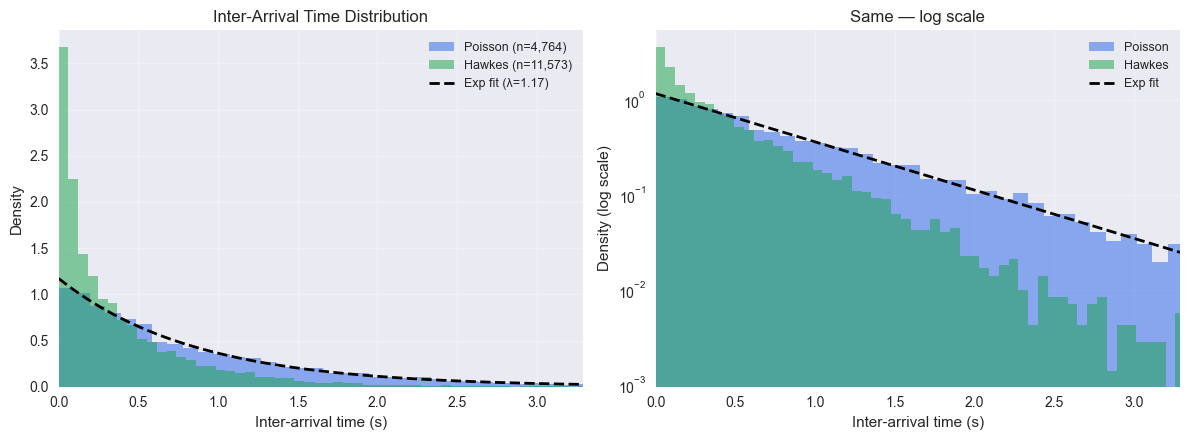

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, mode, color, label in [
    (axes[0], "poisson", C_POISSON, "Poisson"),
    (axes[0], "hawkes",  C_EXCITED, "Hawkes"),
]:
    iat = mc[mode]["iat"]
    if len(iat) > 0:
        ax.hist(iat, bins=80, density=True, alpha=0.5, color=color,
                label=f"{label} (n={len(iat):,})")

# Overlay exponential fit for Poisson
iat_p = mc["poisson"]["iat"]
if len(iat_p) > 0:
    rate = 1.0 / np.mean(iat_p)
    x_exp = np.linspace(0, np.percentile(iat_p, 99), 200)
    axes[0].plot(x_exp, rate * np.exp(-rate * x_exp), color="black", lw=2, ls="--",
                 label=f"Exp fit (λ={rate:.2f})")

axes[0].set_xlabel("Inter-arrival time (s)")
axes[0].set_ylabel("Density")
axes[0].set_title("Inter-Arrival Time Distribution")
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, np.percentile(iat_p, 98) if len(iat_p) > 0 else 5)
axes[0].grid(True, alpha=0.3)

# Log-scale version to see the tail
for mode, color, label in [("poisson", C_POISSON, "Poisson"), ("hawkes", C_EXCITED, "Hawkes")]:
    iat = mc[mode]["iat"]
    if len(iat) > 0:
        axes[1].hist(iat, bins=80, density=True, alpha=0.5, color=color, label=label)

if len(iat_p) > 0:
    axes[1].plot(x_exp, rate * np.exp(-rate * x_exp), color="black", lw=2, ls="--",
                 label="Exp fit")

axes[1].set_xlabel("Inter-arrival time (s)")
axes[1].set_ylabel("Density (log scale)")
axes[1].set_title("Same — log scale")
axes[1].set_yscale("log")
axes[1].set_xlim(0, np.percentile(iat_p, 98) if len(iat_p) > 0 else 5)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

**Comment.** The Hawkes distribution shows a heavier left tail — an excess of
very short inter-arrival times — relative to the exponential benchmark. This is
the signature of fill clustering: after one fill, the next tends to arrive sooner
than the memoryless Poisson model would predict.

### 5.2 Fano Factor (Over-Dispersion)

The **Fano factor** is the ratio variance / mean of the fill count per path.
For a Poisson process, the Fano factor equals exactly 1.
For a Hawkes process with clustering, it exceeds 1 (over-dispersion).
This is a much better quantitative test than eyeballing histograms.

In [8]:
print("=" * 55)
print(f"{'':30s} {'Poisson':>10s} {'Hawkes':>10s}")
print("=" * 55)

for label, key in [("Mean fills/path", "mean"), ("Variance", "var"),
                    ("Fano factor (var/mean)", "fano")]:
    cp = mc["poisson"]["counts"]
    ch = mc["hawkes"]["counts"]
    if key == "mean":
        vp, vh = cp.mean(), ch.mean()
    elif key == "var":
        vp, vh = cp.var(), ch.var()
    else:
        vp = cp.var() / max(cp.mean(), 1e-12)
        vh = ch.var() / max(ch.mean(), 1e-12)
    print(f"{label:30s} {vp:10.2f} {vh:10.2f}")

print("=" * 55)
print("\nFano factor = 1 for Poisson (by definition).")
print("Fano factor > 1 confirms Hawkes over-dispersion (clustering).")

                                  Poisson     Hawkes
Mean fills/path                     10.53      24.15
Variance                             9.45      36.91
Fano factor (var/mean)               0.90       1.53

Fano factor = 1 for Poisson (by definition).
Fano factor > 1 confirms Hawkes over-dispersion (clustering).


### 5.3 Fill Count Histograms

For completeness, we show the total fill count distribution.
Due to aggregation over $T = 10$ s, much of the short-term clustering
is averaged out (CLT effect), so the histogram mainly shows a rightward
shift in the mean rather than dramatic heavy tails.

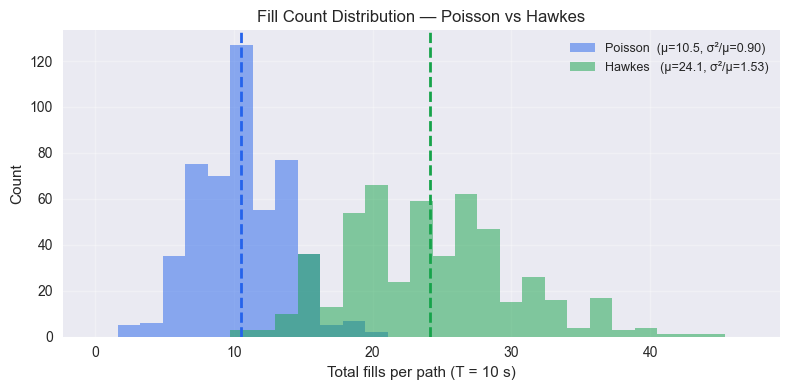

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

cp = mc["poisson"]["counts"]
ch = mc["hawkes"]["counts"]

bins = np.linspace(min(cp.min(), ch.min()) - 2,
                   max(cp.max(), ch.max()) + 2, 30)

ax.hist(cp, bins=bins, color=C_POISSON, alpha=0.5,
        label=f"Poisson  (μ={cp.mean():.1f}, σ²/μ={cp.var()/max(cp.mean(),1e-12):.2f})")
ax.hist(ch, bins=bins, color=C_EXCITED, alpha=0.5,
        label=f"Hawkes   (μ={ch.mean():.1f}, σ²/μ={ch.var()/max(ch.mean(),1e-12):.2f})")

ax.axvline(cp.mean(), color=C_POISSON, lw=2, ls="--")
ax.axvline(ch.mean(), color=C_EXCITED, lw=2, ls="--")

ax.set_xlabel("Total fills per path (T = 10 s)")
ax.set_ylabel("Count")
ax.set_title("Fill Count Distribution — Poisson vs Hawkes")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

**Comment.** Hawkes excitation increases both the mean and dispersion of total
fills. However, aggregation over a 10-second horizon smooths out much of the
short-term clustering, so the histogram mainly shows a rightward shift rather
than a dramatic heavy-tail effect. The Fano factor (printed above) is the
better quantitative measure of over-dispersion.

### 5.4 Sample Path: Fill Times on a Timeline

To directly visualise clustering, we plot the fill times for a few
individual paths as a raster plot (event times on a timeline).

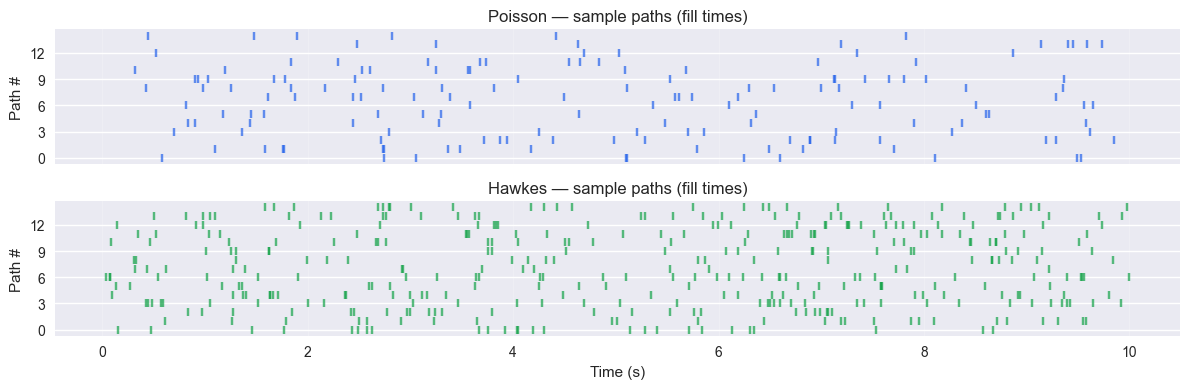

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)

n_show = min(15, len(mc["poisson"]["fill_times"]))

for ax, mode, color, title in [
    (axes[0], "poisson", C_POISSON, "Poisson — sample paths (fill times)"),
    (axes[1], "hawkes",  C_EXCITED, "Hawkes — sample paths (fill times)"),
]:
    for i in range(n_show):
        ft = mc[mode]["fill_times"][i]
        ax.scatter(ft, np.full_like(ft, i), marker="|", s=30, color=color, alpha=0.7)

    ax.set_ylabel("Path #")
    ax.set_title(title)
    ax.set_yticks(range(0, n_show, 3))
    ax.grid(True, alpha=0.2, axis="x")

axes[1].set_xlabel("Time (s)")
fig.tight_layout()
plt.show()

**Comment.** In the Hawkes panel, fills visibly cluster in short bursts,
with gaps between clusters. In the Poisson panel, fills are more
uniformly spread. This is the **direct visual signature** of self-excitation.

### 5.5 Rolling Fill Count — Short-Window Burstiness

Another way to visualise clustering: count fills in short rolling windows
and compare the distribution of counts. Under Poisson, counts in any
window follow $\text{Poisson}(\lambda \cdot w)$. Under Hawkes, we expect
occasional windows with many more fills than the Poisson model predicts.

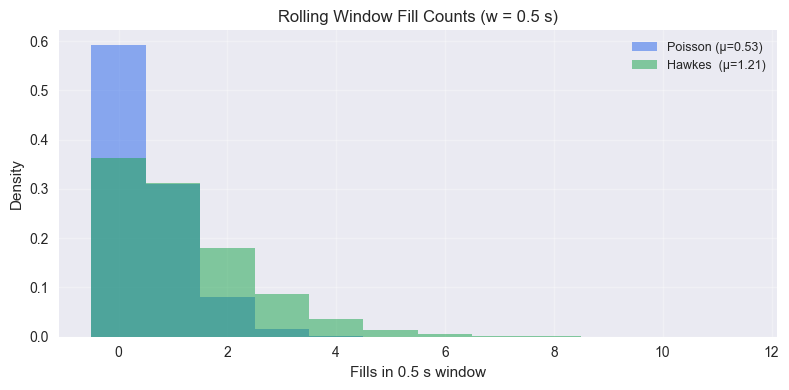

In [11]:
def rolling_counts(fill_times_list, T, window=0.5):
    """Count fills in rolling windows of width `window` across all paths."""
    all_counts = []
    edges = np.arange(0, T - window + 0.001, window / 2)  # 50% overlap
    for ft in fill_times_list:
        if len(ft) == 0:
            all_counts.extend([0] * len(edges))
            continue
        for start in edges:
            c = np.sum((ft >= start) & (ft < start + window))
            all_counts.append(c)
    return np.array(all_counts)

rc_p = rolling_counts(mc["poisson"]["fill_times"], T=10.0, window=0.5)
rc_h = rolling_counts(mc["hawkes"]["fill_times"],  T=10.0, window=0.5)

fig, ax = plt.subplots(figsize=(8, 4))
max_count = max(rc_p.max(), rc_h.max())
bins = np.arange(-0.5, max_count + 1.5, 1)

ax.hist(rc_p, bins=bins, density=True, color=C_POISSON, alpha=0.5,
        label=f"Poisson (μ={rc_p.mean():.2f})")
ax.hist(rc_h, bins=bins, density=True, color=C_EXCITED, alpha=0.5,
        label=f"Hawkes  (μ={rc_h.mean():.2f})")

ax.set_xlabel("Fills in 0.5 s window")
ax.set_ylabel("Density")
ax.set_title("Rolling Window Fill Counts (w = 0.5 s)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

**Comment.** The Hawkes distribution has a heavier right tail: more windows
with 3, 4, 5+ fills than the Poisson model predicts. These are the
"bursts" caused by self-excitation. Conversely, the Hawkes model also
has more empty windows (the quiet periods between bursts).

---
## 6. Implications for Market Making

### What Hawkes dynamics break in the Guéant framework

The Guéant (2017) ODE reduction relies on a **2D state space** $(t, q)$:
the only variables that matter for optimal quotes are time and inventory.

With Hawkes fills, the excitation states $(y_{\text{bid}}, y_{\text{ask}})$
become **additional state variables**. The effective state space expands
from 2D to 4D: $(t, q, y_b, y_a)$.

This breaks the dimensional reduction that makes the ODE tractable:

| | Poisson | Hawkes |
|---|---|---|
| State space | $(t, q)$ — 2D | $(t, q, y_b, y_a)$ — 4D |
| ODE tractable? | ✅ Yes | ❌ No |
| Optimal policy | Closed-form available | Must approximate (RL, etc.) |

### What this motivates

- **Reinforcement learning** approaches that can handle the expanded state
  space (see Notebook 10)
- **Regime-aware** policies that adapt to time-varying fill intensities
  (see Notebook 11)
- **Model mismatch** analysis: applying the Guéant policy in a Hawkes world
  leads to suboptimal performance (explored in the dashboard, Page 1 §6)


This notebook is a **stylized demonstration** of execution clustering, not a
calibrated empirical comparison with the original Guéant model. The parameters
are chosen to make the effects visible. In a real-world setting, the Hawkes
parameters would need to be calibrated from order flow data, and the optimal
policy would need to be recomputed numerically (e.g., via PDE methods on the
expanded state space, or via RL).